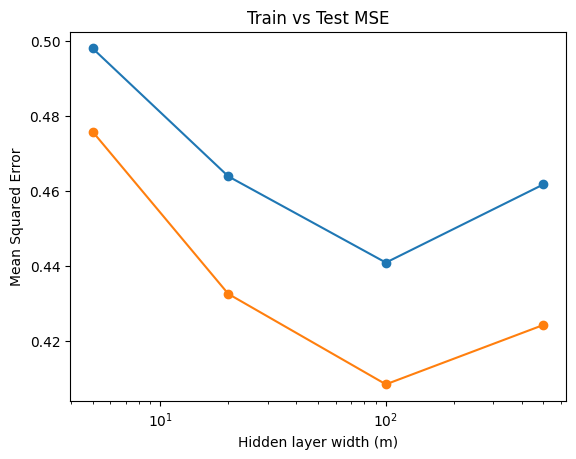

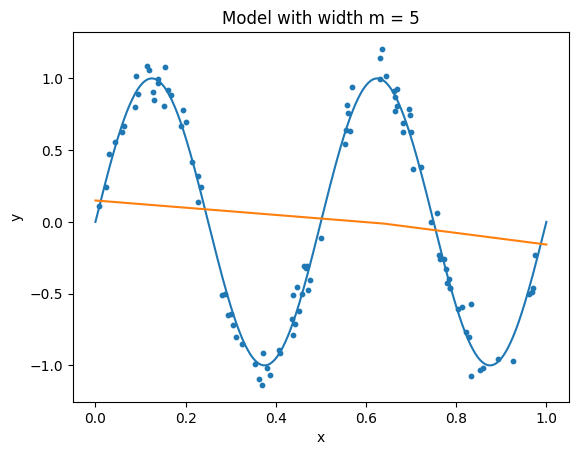

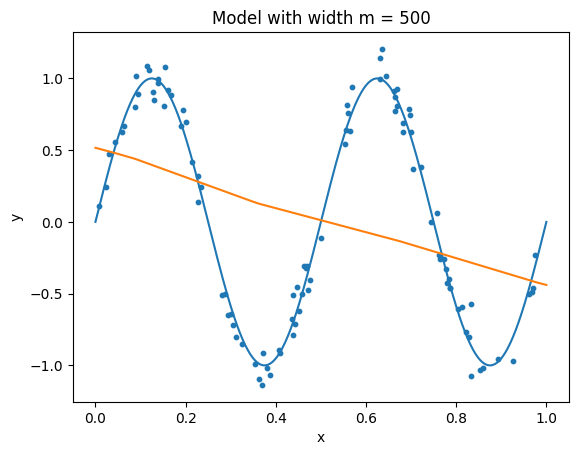

Widths: [5, 20, 100, 500]
Train MSE: [np.float64(0.4979212455836366), np.float64(0.46380289265402985), np.float64(0.4408235647813534), np.float64(0.46166931878629386)]
Test MSE: [np.float64(0.47572642608781196), np.float64(0.4324831135944527), np.float64(0.4083919032277322), np.float64(0.42421683983892366)]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# Set random seed for reproducibility
rng = np.random.default_rng(42)

# Target function
def f(x):
    return np.sin(4 * np.pi * x)

# Generate training and test data
n_train = 100
n_test = 1000

X_train = rng.uniform(0, 1, size=(n_train, 1))
y_train = f(X_train[:, 0]) + rng.normal(0, 0.1, size=n_train)

X_test = rng.uniform(0, 1, size=(n_test, 1))
y_test = f(X_test[:, 0]) + rng.normal(0, 0.1, size=n_test)

widths = [5, 20, 100, 500]
train_mse = []
test_mse = []
models = {}

for m in widths:
    model = MLPRegressor(
        hidden_layer_sizes=(m,),
        activation="relu",
        solver="adam",
        max_iter=5000,
        random_state=42,
    )
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mse.append(mean_squared_error(y_train, y_train_pred))
    test_mse.append(mean_squared_error(y_test, y_test_pred))
    models[m] = model

# Plot MSE vs width
plt.figure()
plt.plot(widths, train_mse, marker='o')
plt.plot(widths, test_mse, marker='o')
plt.xlabel("Hidden layer width (m)")
plt.ylabel("Mean Squared Error")
plt.title("Train vs Test MSE")
plt.xscale("log")
plt.show()

# Plot predictions for smallest and largest networks
x_plot = np.linspace(0, 1, 500).reshape(-1, 1)
y_true_plot = f(x_plot[:, 0])

for m in [5, 500]:
    plt.figure()
    plt.plot(x_plot[:, 0], y_true_plot)
    plt.scatter(X_train[:, 0], y_train, s=10)
    plt.plot(x_plot[:, 0], models[m].predict(x_plot))
    plt.title(f"Model with width m = {m}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

print("Widths:", widths)
print("Train MSE:", train_mse)
print("Test MSE:", test_mse)


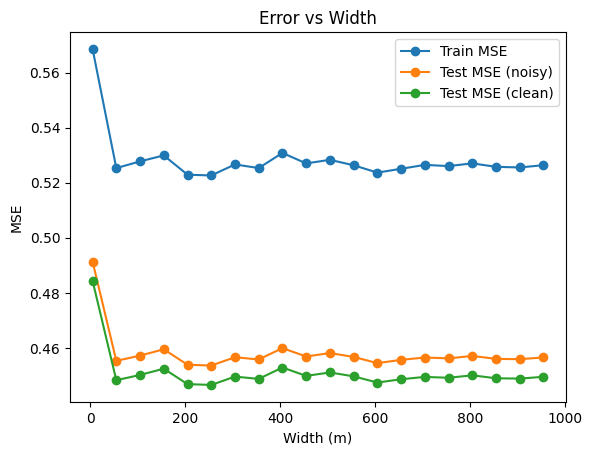

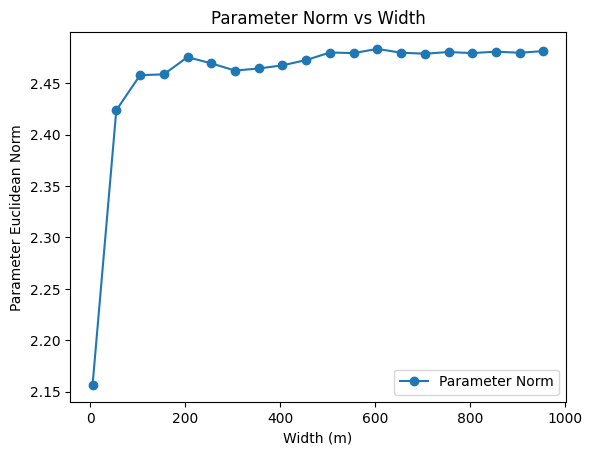

Widths: [5, 55, 105, 155, 205, 255, 305, 355, 405, 455, 505, 555, 605, 655, 705, 755, 805, 855, 905, 955]
Train MSE: [0.5686178227256724, 0.5253152362274165, 0.5277588124355483, 0.5299245428051214, 0.5229217043018812, 0.5226375828999299, 0.5266488609401452, 0.5253356622040074, 0.530824840611242, 0.5270230675741925, 0.5283245117808255, 0.5263532765788206, 0.5236772147727782, 0.5250677087843009, 0.5264951177339379, 0.5260467665617512, 0.5270378485621521, 0.5257794594713372, 0.5255563252507763, 0.5263748641452539]
Test MSE (noisy): [0.4913771955588778, 0.45529219075279687, 0.4571875255313046, 0.4594829439775995, 0.4538739622059966, 0.4535816788681332, 0.45660052432364184, 0.4557847459752328, 0.45990677020396975, 0.45686398276089674, 0.45811275295342446, 0.4567190862361473, 0.4544574473862376, 0.455650495253303, 0.45649769818538577, 0.4561836360700388, 0.4570716313561264, 0.45600567129867164, 0.45588785728861014, 0.4565374409347681]
Test MSE (clean): [0.4843903927252729, 0.4482560038504168

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

rng = np.random.default_rng(10)

def f(x):
    return np.sin(4 * np.pi * x)

# Data
n_train = 50
n_test = 1000
noise_std = 0.1

X_train = rng.uniform(0, 1, size=(n_train, 1))
y_train_clean = f(X_train[:, 0])
y_train = y_train_clean + rng.normal(0, noise_std, size=n_train)

X_test = rng.uniform(0, 1, size=(n_test, 1))
y_test_clean = f(X_test[:, 0])
y_test_noisy = y_test_clean + rng.normal(0, noise_std, size=n_test)

widths = list(range(5, 1001, 50))
n_repeats = 5

results = {m: {"train": [], "test_noisy": [], "test_clean": [], "norm": []} for m in widths}
models = {}

for m in widths:
    for rep in range(n_repeats):
        model = MLPRegressor(
            hidden_layer_sizes=(m,),
            activation="relu",
            solver="sgd",
            alpha=0.0,
            max_iter=500_000,
            random_state=rep,
        )
        model.fit(X_train, y_train)

        y_train_pred = model.predict(X_train)
        y_test_pred = model.predict(X_test)

        train_err = mean_squared_error(y_train, y_train_pred)
        test_noisy_err = mean_squared_error(y_test_noisy, y_test_pred)
        test_clean_err = mean_squared_error(y_test_clean, y_test_pred)

        # Parameter norm
        sq_sum = 0.0
        for coef, intercept in zip(model.coefs_, model.intercepts_):
            sq_sum += np.sum(coef**2) + np.sum(intercept**2)
        param_norm = np.sqrt(sq_sum)

        results[m]["train"].append(train_err)
        results[m]["test_noisy"].append(test_noisy_err)
        results[m]["test_clean"].append(test_clean_err)
        results[m]["norm"].append(param_norm)

        models[m] = model

# Aggregate means
train_means = [np.mean(results[m]["train"]) for m in widths]
test_noisy_means = [np.mean(results[m]["test_noisy"]) for m in widths]
test_clean_means = [np.mean(results[m]["test_clean"]) for m in widths]
norm_means = [np.mean(results[m]["norm"]) for m in widths]

# Plot errors vs width
plt.figure()
plt.plot(widths, train_means, marker='o', label='Train MSE')
plt.plot(widths, test_noisy_means, marker='o', label='Test MSE (noisy)')
plt.plot(widths, test_clean_means, marker='o', label='Test MSE (clean)')
# plt.xscale("log")
plt.xlabel("Width (m)")
plt.ylabel("MSE")
plt.title("Error vs Width")
plt.legend()
plt.show()

# Plot parameter norm vs width
plt.figure()
plt.plot(widths, norm_means, marker='o', label='Parameter Norm')
# plt.xscale("log")
plt.xlabel("Width (m)")
plt.ylabel("Parameter Euclidean Norm")
plt.title("Parameter Norm vs Width")
plt.legend()
plt.show()

print("Widths:", widths)
print("Train MSE:", train_means)
print("Test MSE (noisy):", test_noisy_means)
print("Test MSE (clean):", test_clean_means)
print("Param Norms:", norm_means)


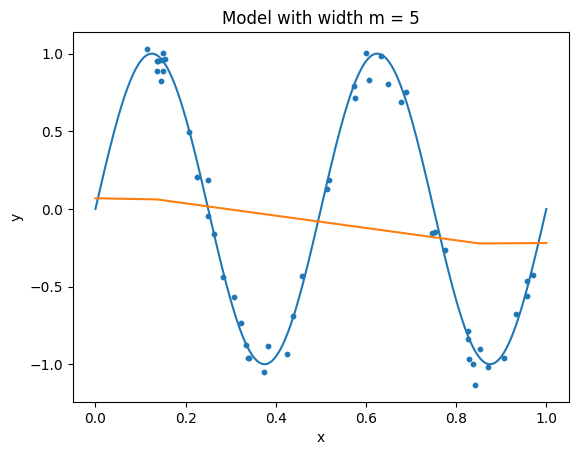

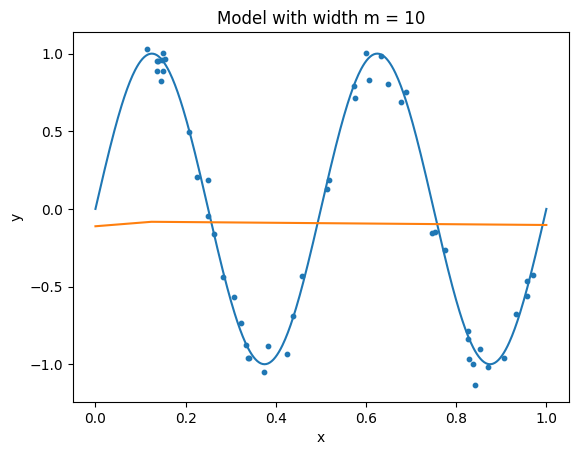

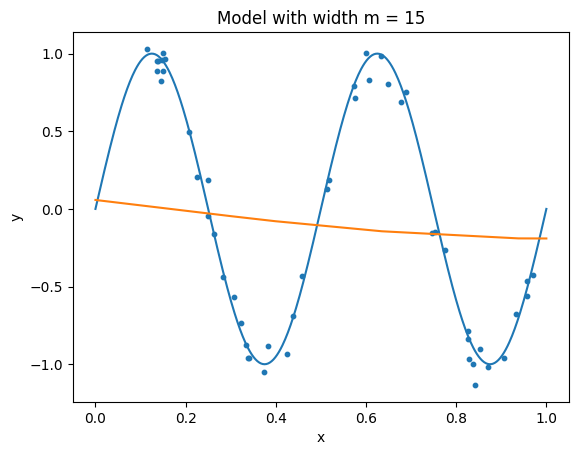

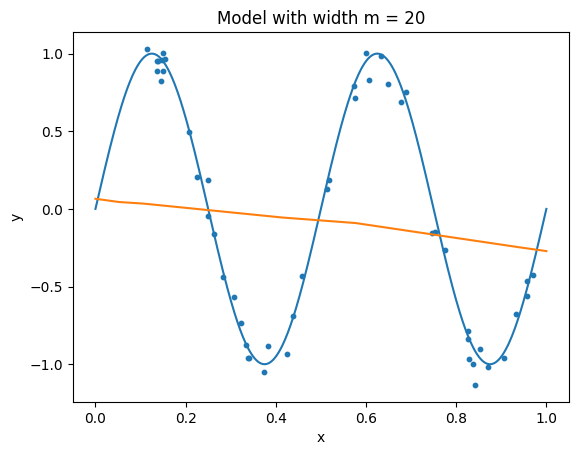

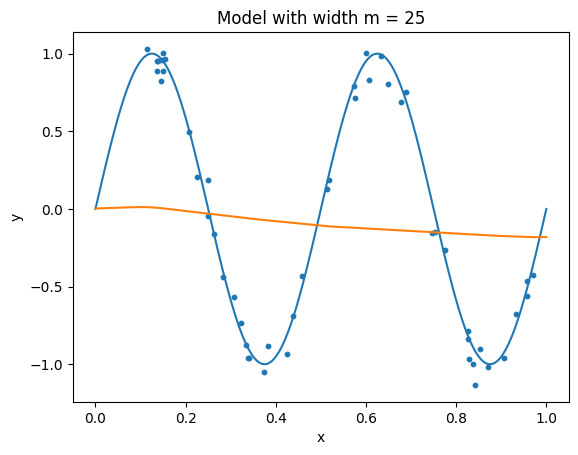

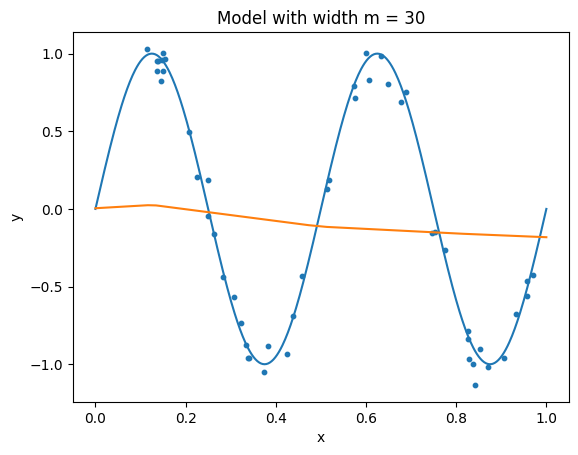

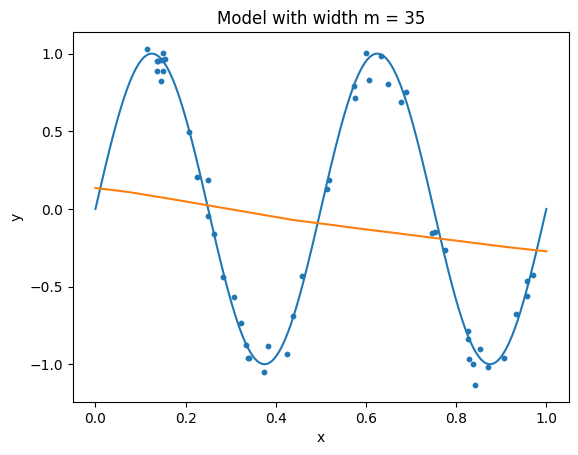

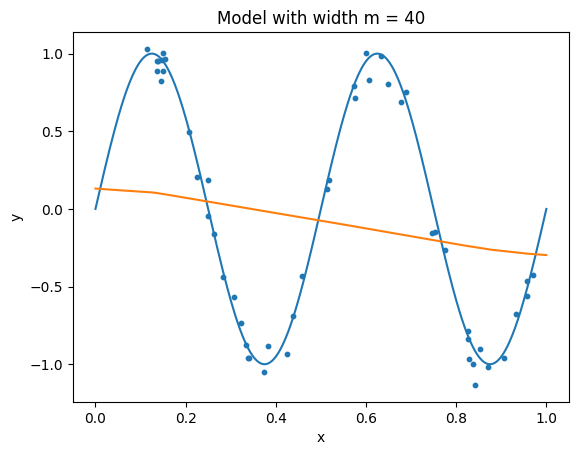

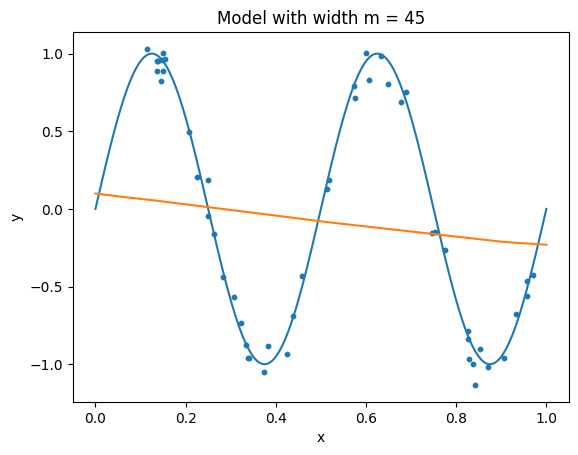

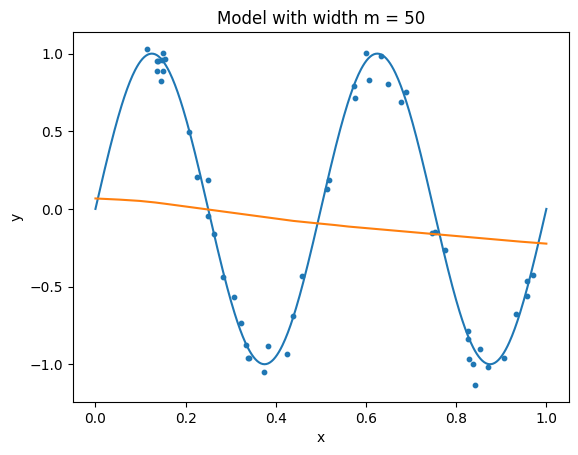

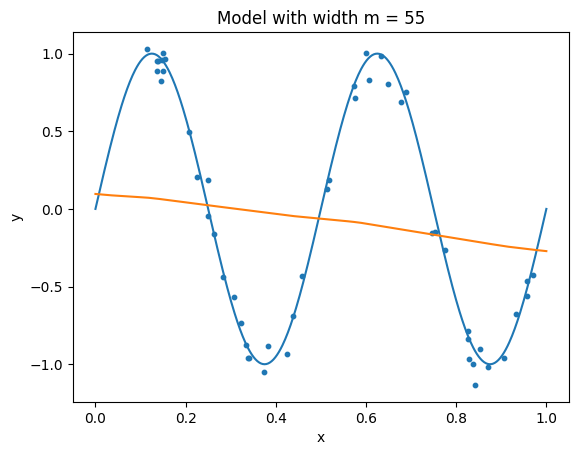

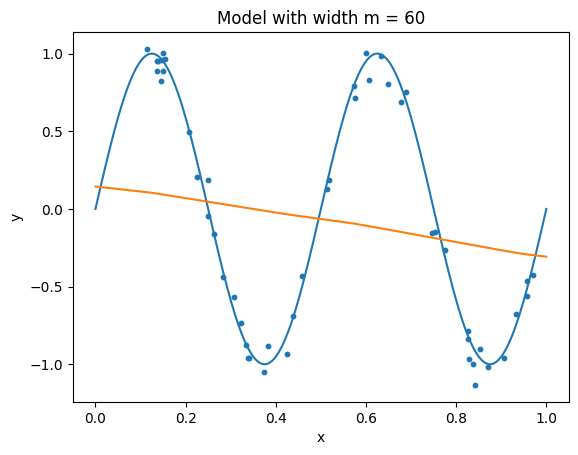

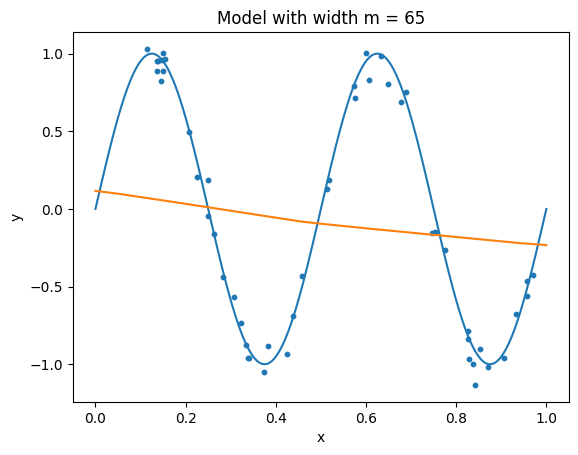

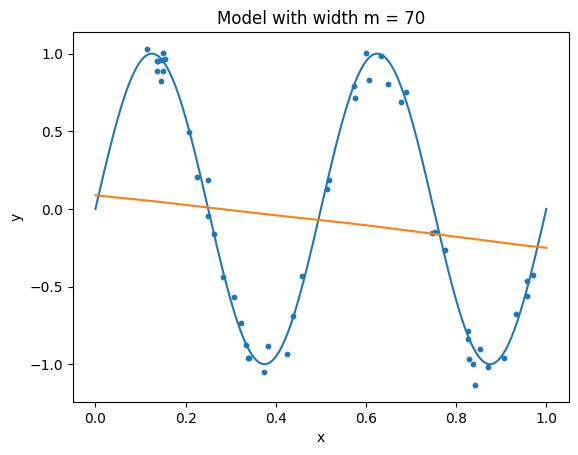

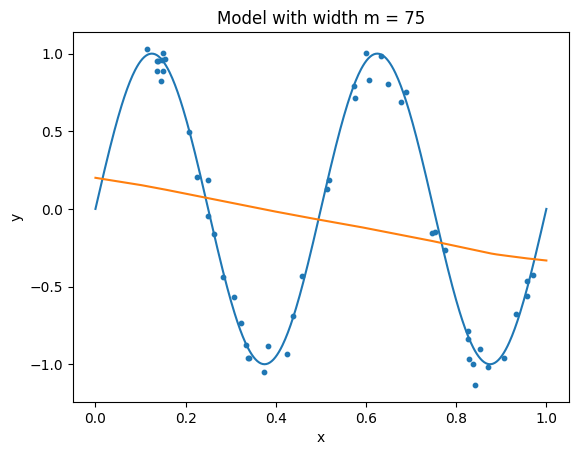

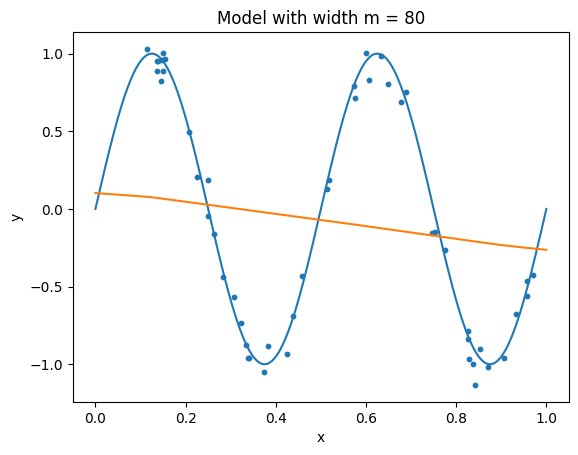

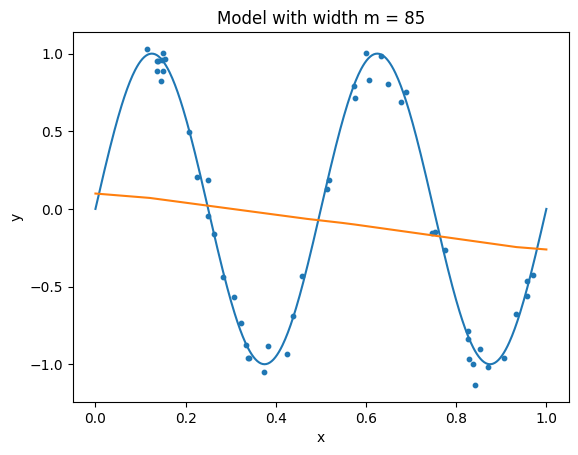

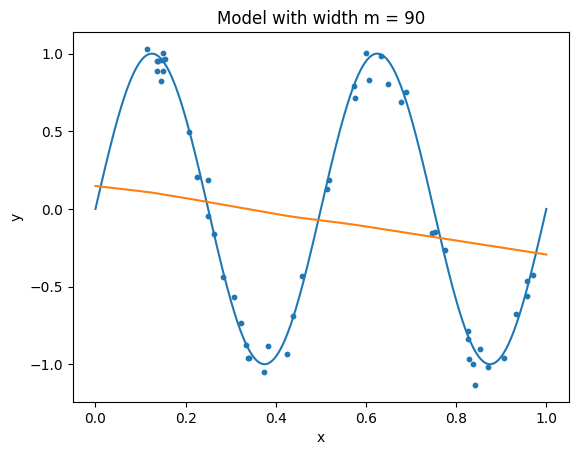

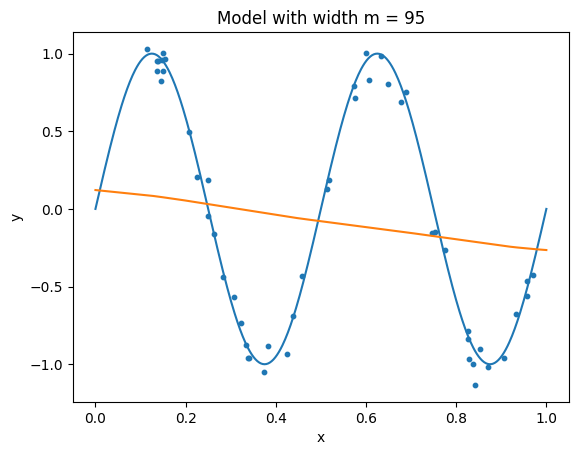

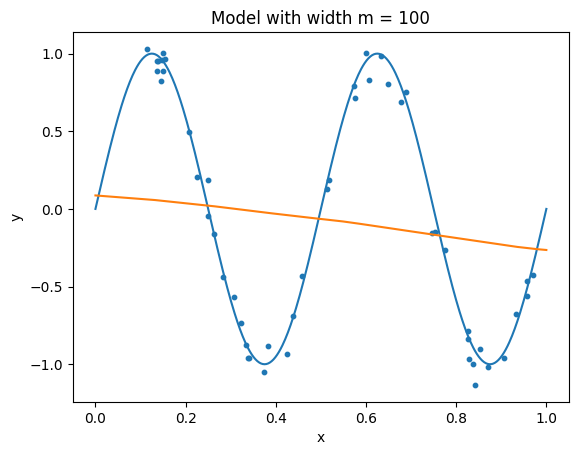

In [14]:

# Plot predictions for smallest and largest networks
x_plot = np.linspace(0, 1, 500).reshape(-1, 1)
y_true_plot = f(x_plot[:, 0])

for m in widths:
    plt.figure()
    plt.plot(x_plot[:, 0], y_true_plot)
    plt.scatter(X_train[:, 0], y_train, s=10)
    plt.plot(x_plot[:, 0], models[m].predict(x_plot))
    plt.title(f"Model with width m = {m}")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()